<a href="https://colab.research.google.com/github/vicky-ssingh/Feature_Matching_ORB/blob/main/Feature_Matching_ORB_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Feature Matching Between Two Images (ORB + BFMatcher)

**Objective:**  
This lab demonstrates how to detect features, compute descriptors, and match them between two images using **ORB**, **BFMatcher**, and **Ratio Test**.

This notebook is **beginner-friendly**, with step-by-step explanations and comments.

---
### Libraries Used
- OpenCV (`cv2`)
- NumPy
- Matplotlib

---


In [ ]:

# Step 1: Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt



### Step 2: Load Images

≡ƒôî **Note:**  
- Add two images in the **same folder** as this notebook  
- Name them: `img1.jpg` and `img2.jpg`


In [ ]:

# Load images in grayscale
img1 = cv2.imread('img1.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('img2.png', cv2.IMREAD_GRAYSCALE)

# Check if images are loaded
if img1 is None or img2 is None:
    print("Error: Please add img1.jpg and img2.jpg in the same folder.")
else:
    print("Images loaded successfully!")


Images loaded successfully!



### Step 3: Initialize ORB Detector

ORB detects **keypoints** and computes **descriptors**


In [ ]:

# Create ORB object
orb = cv2.ORB_create(nfeatures=1000)

# Detect keypoints and descriptors
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

print(f"Keypoints in Image 1: {len(kp1)}")
print(f"Keypoints in Image 2: {len(kp2)}")


Keypoints in Image 1: 761
Keypoints in Image 2: 658



### Step 4: Match Features using BFMatcher

We use:
- **Hamming distance** (best for ORB)
- **KNN matching (k=2)**


In [ ]:

# Create BFMatcher
bf = cv2.BFMatcher(cv2.NORM_HAMMING)

# KNN match
matches = bf.knnMatch(des1, des2, k=2)

print("Total raw matches:", len(matches))


Total raw matches: 761



### Step 5: Apply Ratio Test (LoweΓÇÖs Ratio Test)

This removes **false matches**


In [ ]:

# Apply ratio test
good_matches = []

for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print("Good matches after ratio test:", len(good_matches))


Good matches after ratio test: 9



### Step 6: Draw Matches

Visualize matched keypoints between two images


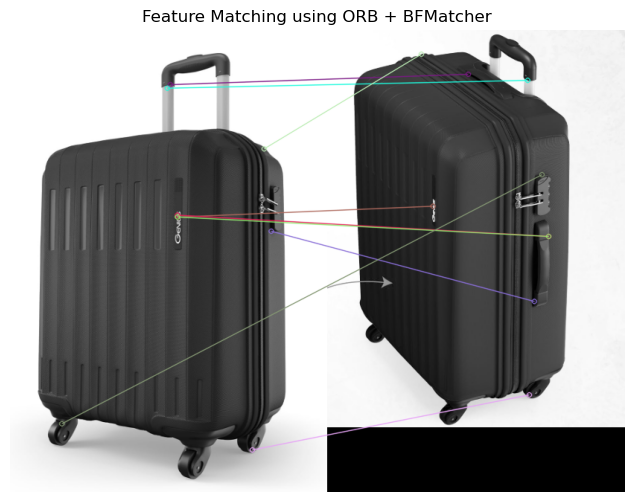

In [ ]:

# Draw matches
matched_img = cv2.drawMatches(
    img1, kp1,
    img2, kp2,
    good_matches[:50],  # show top 50 matches
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# Display result
plt.figure(figsize=(15,6))
plt.imshow(matched_img, cmap='gray')
plt.axis('off')
plt.title("Feature Matching using ORB + BFMatcher")
plt.show()



## Γ£à Lab Completed

### What You Added (As Asked):
Γ£ö Feature matching between two images  
Γ£ö BFMatcher + Ratio Test  
Γ£ö drawMatches visualization  

---
### ≡ƒº¬ Experiment Ideas (Optional):
- Change ORB features count
- Try SIFT (if available)
- Use FLANN Matcher

---
### ≡ƒôü What You Need to Add:
- Two images: `img1.jpg` and `img2.jpg`

---
Happy Learning ≡ƒÜÇ
